# Step 5 — Classification Under Formatting Stress

Feeds the degraded (extracted) text from Step 4 through **both** trained classifiers —
TF-IDF+SVM and fine-tuned DistilBERT — and measures accuracy/F1 **per layout condition**,
compared against the clean baseline from Step 2 (SVM: 99.31%, DistilBERT: 95.14%).

This is the core experiment of the whole project: does formatting-induced text degradation
actually hurt classification accuracy, and does it hurt one model more than the other?

**Note on the SVM baseline:** the TF-IDF+SVM model itself wasn't saved to disk in the earlier
notebook (only DistilBERT was saved), so this notebook quickly retrains it on the same clean
data — this takes seconds, unlike DistilBERT fine-tuning.

In [10]:
# Install dependencies (skip if already installed)
import sys
!{sys.executable} -m pip install -q transformers torch scikit-learn pandas matplotlib seaborn


In [11]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SEED = 42
DATA_PATH = "UpdatedResumeDataSet.csv"              # original clean dataset (Step 1)
DEGRADATION_CSV = "degradation_results.csv"          # produced by Step 4
DISTILBERT_DIR = "./distilbert_resume_finetuned"     # saved model folder from Step 2

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: mps


## Rebuild the clean baseline (label encoder + SVM)

We need the *same* label encoding used originally (so label IDs line up with the saved
DistilBERT model's classification head), and we need to retrain the SVM since it wasn't
persisted to disk. Both are fast — this reproduces Step 1/Step 2's setup exactly.


In [12]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^A-Za-z0-9\s.,;:()/#+-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df = pd.read_csv(DATA_PATH)
col_map = {c.lower(): c for c in df.columns}
text_col = col_map.get("resume") or col_map.get("resume_str") or col_map.get("text")
label_col = col_map.get("category") or col_map.get("label")
df = df[[label_col, text_col]].rename(columns={label_col: "Category", text_col: "Resume"})
df = df.dropna(subset=["Category", "Resume"]).reset_index(drop=True)
df["clean_text"] = df["Resume"].apply(clean_text)

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Category"])
num_labels = df["label"].nunique()
print(f"Loaded {len(df)} resumes, {num_labels} categories")

# Same 70/15/15 split as Step 1 (same SEED = same split)
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label"])
test_df, heldout_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])
print(f"Train: {len(train_df)} | Test: {len(test_df)} | Held-out: {len(heldout_df)}")


Loaded 962 resumes, 25 categories
Train: 673 | Test: 144 | Held-out: 145


In [13]:
# Retrain TF-IDF + SVM (fast - seconds, not saved to disk originally)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_train_tfidf = tfidf.fit_transform(train_df["clean_text"])
svm_clf = LinearSVC(random_state=SEED)
svm_clf.fit(X_train_tfidf, train_df["label"])

# Sanity check: confirm this matches the original clean-baseline accuracy from Step 2
X_test_tfidf = tfidf.transform(test_df["clean_text"])
svm_test_preds = svm_clf.predict(X_test_tfidf)
svm_clean_acc = accuracy_score(test_df["label"], svm_test_preds)
print(f"SVM clean-test accuracy (sanity check, should be ~0.99): {svm_clean_acc:.4f}")


SVM clean-test accuracy (sanity check, should be ~0.99): 0.9931


## Load the saved DistilBERT model

In [14]:
tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_DIR)
bert_model = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_DIR)
bert_model.to(DEVICE)
bert_model.eval()
print("DistilBERT loaded from", DISTILBERT_DIR)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT loaded from ./distilbert_resume_finetuned


## Load Step 4's degraded text and run both models

For each row (one resume × one layout condition), predict the category using both models on
the **extracted** (potentially degraded) text, then compare against the true category.


In [15]:
degradation_df = pd.read_csv(DEGRADATION_CSV)
print(f"Loaded {len(degradation_df)} rows across conditions: {degradation_df['condition'].unique()}")

# True labels, using the SAME label encoder as training (so IDs match)
degradation_df["true_label"] = label_encoder.transform(degradation_df["category"])

TEXT_COLUMN = "extracted_text_pymupdf"   # switch to 'extracted_text_plumber' to compare extractors
degradation_df[TEXT_COLUMN] = degradation_df[TEXT_COLUMN].fillna("").apply(clean_text)


Loaded 580 rows across conditions: ['clean' 'two_column' 'table_based' 'icon_headers']


In [16]:
# ---- SVM predictions on degraded text ----
X_degraded_tfidf = tfidf.transform(degradation_df[TEXT_COLUMN])
degradation_df["svm_pred"] = svm_clf.predict(X_degraded_tfidf)

# ---- DistilBERT predictions on degraded text (batched) ----
def predict_bert_batch(texts, batch_size=16, max_len=256):
    all_preds = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])
        enc = tokenizer(batch, truncation=True, padding="max_length", max_length=max_len, return_tensors="pt")
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            logits = bert_model(**enc).logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
    return all_preds

degradation_df["bert_pred"] = predict_bert_batch(degradation_df[TEXT_COLUMN].tolist())
print("Predictions complete.")
degradation_df[["resume_id", "condition", "true_label", "svm_pred", "bert_pred"]].head(10)


Predictions complete.


,resume_id,condition,true_label,svm_pred,bert_pred
0,0,clean,3,3,3
1,0,two_column,3,3,3
2,0,table_based,3,3,3
3,0,icon_headers,3,3,3
4,1,clean,15,15,15
5,1,two_column,15,15,15
6,1,table_based,15,15,15
7,1,icon_headers,15,15,15
8,2,clean,18,18,18
9,2,two_column,18,18,18


## Accuracy / F1 per layout condition

This table is the central result of the project — compare each row against the clean
baseline (SVM: 99.31% / DistilBERT: 95.14%) to see how much each model's accuracy drops
under each type of formatting distortion.

In [17]:
CLEAN_BASELINE = {"svm_accuracy": 0.9931, "svm_f1": 0.9932, "bert_accuracy": 0.9514, "bert_f1": 0.9446}

results = []
for cond, group in degradation_df.groupby("condition"):
    results.append({
        "condition": cond,
        "svm_accuracy": accuracy_score(group["true_label"], group["svm_pred"]),
        "svm_f1": f1_score(group["true_label"], group["svm_pred"], average="weighted", zero_division=0),
        "bert_accuracy": accuracy_score(group["true_label"], group["bert_pred"]),
        "bert_f1": f1_score(group["true_label"], group["bert_pred"], average="weighted", zero_division=0),
    })

results_df = pd.DataFrame(results)

# Add the clean baseline as a reference row
baseline_row = {"condition": "clean_baseline (Step 2)", **CLEAN_BASELINE}
results_df = pd.concat([pd.DataFrame([baseline_row]), results_df], ignore_index=True)

# Compute accuracy drop relative to clean baseline
results_df["svm_accuracy_drop"] = CLEAN_BASELINE["svm_accuracy"] - results_df["svm_accuracy"]
results_df["bert_accuracy_drop"] = CLEAN_BASELINE["bert_accuracy"] - results_df["bert_accuracy"]

results_df.to_csv("classification_under_stress_results.csv", index=False)
results_df


,condition,svm_accuracy,svm_f1,bert_accuracy,bert_f1,svm_accuracy_drop,bert_accuracy_drop
0,clean_baseline (Step 2),0.9931,0.9932,0.951400,0.944600,0.0000,0.000000
1,clean,1.0000,1.0000,0.958621,0.951522,-0.0069,-0.007221
2,icon_headers,1.0000,1.0000,0.924138,0.912451,-0.0069,0.027262
3,table_based,1.0000,1.0000,0.958621,0.951522,-0.0069,-0.007221
4,two_column,1.0000,1.0000,0.958621,0.951522,-0.0069,-0.007221


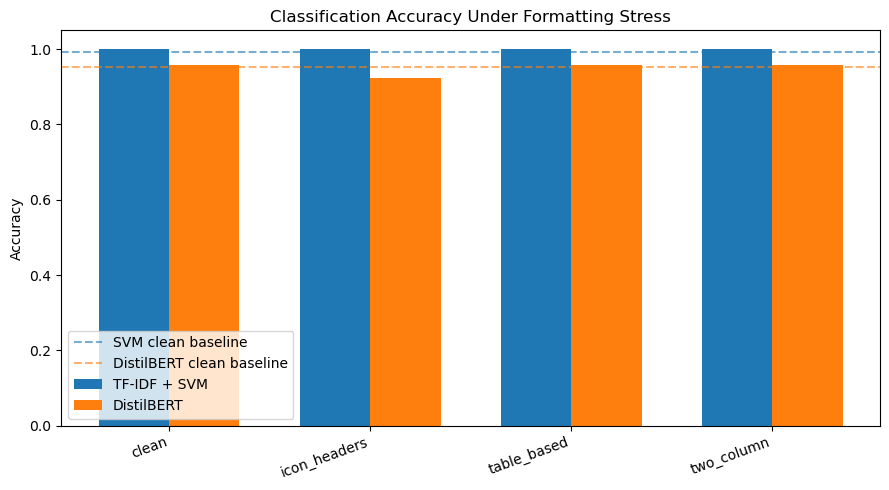

In [18]:
# Visualize accuracy drop by condition, per model
plot_df = results_df[results_df["condition"] != "clean_baseline (Step 2)"]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df))
width = 0.35
ax.bar(x - width/2, plot_df["svm_accuracy"], width, label="TF-IDF + SVM")
ax.bar(x + width/2, plot_df["bert_accuracy"], width, label="DistilBERT")
ax.axhline(CLEAN_BASELINE["svm_accuracy"], color="C0", linestyle="--", alpha=0.6, label="SVM clean baseline")
ax.axhline(CLEAN_BASELINE["bert_accuracy"], color="C1", linestyle="--", alpha=0.6, label="DistilBERT clean baseline")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["condition"], rotation=20, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Classification Accuracy Under Formatting Stress")
ax.legend()
plt.tight_layout()
plt.savefig("accuracy_under_stress.png", dpi=150)
plt.show()


In [19]:
degradation_df["svm_correct"] = (degradation_df["svm_pred"] == degradation_df["true_label"]).astype(int)
degradation_df["bert_correct"] = (degradation_df["bert_pred"] == degradation_df["true_label"]).astype(int)
degradation_df.to_csv("per_resume_predictions.csv", index=False)
print("Saved per_resume_predictions.csv")

Saved per_resume_predictions.csv
